# Particle-filter test harness

Set `run_to_test` below to any recording in the `Runs/` folder and run all cells. The notebook
detects steps, runs the particle filter from a **global cold start** (no known start position or
floor) and plots the estimated trajectory on both floor plans.

This file deliberately contains only what is needed to localize one recording: the map, the
constants calibrated in `localization.ipynb`, step detection, and the filter itself. There is no
ground truth, no calibration and no evaluation here — `localization.ipynb` remains the place where
the model is derived and validated.

In [12]:
run_to_test = 'R1_S25Ultra.csv'          # <-- any CSV in the Runs/ folder

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, find_peaks, sosfiltfilt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Runs').is_dir()), None)
assert ROOT is not None, 'Run this notebook from inside the project folder.'
RUNS, PLAN_DIR = ROOT / 'Runs', ROOT / 'Project_Description'

recording = RUNS / (run_to_test if run_to_test.endswith('.csv') else run_to_test + '.csv')
assert recording.exists(), (f'{recording.name} not found. Available: '
                            + ', '.join(sorted(p.name for p in RUNS.glob('R*.csv'))))
run_id, device_key = recording.stem.split('_', 1)[0], recording.stem.split('_', 1)[1].lower()
print(f'testing {recording.name}   (run {run_id}, device {device_key})')

testing R1_S25Ultra.csv   (run R1, device s25ultra)


## 1. Map and calibrated constants

The corridor centre lines, beacon positions and staircases are the Phase 3 map. The BLE path-loss
model and the per-phone RSSI offsets were fitted once in `localization.ipynb` against ground-truth
positions and are properties of this building and these beacons, not of any single run, so they are
simply applied here. A phone that is not in the offset table gets 0 dB, which is safe because the
filter's likelihood is invariant to a constant gain error anyway.

In [13]:
CORRIDOR_WIDTH_M = 3.26
WALL_CLEARANCE_M = 0.30
WALKABLE_HALF_WIDTH_M = CORRIDOR_WIDTH_M / 2 - WALL_CLEARANCE_M
FLOOR_SEP_M = 3.5

plan_meta = {
    0: {'file': 'Floormap_0 (1).png', 'x_scale': 34 / (932 - 218), 'x_origin': 40.0,
        'y_scale': 3.26 / (181 - 113), 'y_center': 147.0},
    1: {'file': 'floormap_1 (1).png', 'x_scale': 34 / (977 - 259), 'x_origin': 80.0,
        'y_scale': 3.26 / (187 - 120), 'y_center': 153.5},
}

def pixel_to_metric(floor, pixel):
    meta = plan_meta[floor]
    return ((pixel[0] - meta['x_origin']) * meta['x_scale'],
            (meta['y_center'] - pixel[1]) * meta['y_scale'])

def metric_to_pixel_xy(floor, x, y):
    meta = plan_meta[floor]
    return (np.asarray(x) / meta['x_scale'] + meta['x_origin'],
            meta['y_center'] - np.asarray(y) / meta['y_scale'])

centerline_pixels = {
    0: [[(40, 185), (190, 185), (190, 147), (935, 147), (1045, 150)], [(113, 190), (113, 109)],
        [(1035, 150), (1035, 410)], [(975, 150), (975, 370)]],
    1: [[(0, 190), (210, 190), (210, 153.5), (950, 153.5), (1055, 150)], [(143, 198), (143, 107)],
        [(1055, 150), (1055, 410)], [(995, 150), (995, 370)]],
}
map_edges = pd.DataFrame([
    {'floor': f, 'x1': pixel_to_metric(f, a)[0], 'y1': pixel_to_metric(f, a)[1],
     'x2': pixel_to_metric(f, b)[0], 'y2': pixel_to_metric(f, b)[1]}
    for f, lines in centerline_pixels.items() for line in lines
    for a, b in zip(line[:-1], line[1:])])

beacon_pixels = {'arrive_emi1': (1, (164, 210)), 'arrive_emi2': (1, (423, 177)),
                 'arrive_emi3': (1, (975, 115)), 'arrive_emi4': (0, (960, 105)),
                 'arrive_emi8': (0, (130, 205)), 'arrive_emi10': (0, (648, 170))}
beacon_points = pd.DataFrame([
    {'beacon': b, 'floor': f, 'pixel_x': p[0], 'pixel_y': p[1],
     'x_m': pixel_to_metric(f, p)[0], 'y_m': pixel_to_metric(f, p)[1]}
    for b, (f, p) in beacon_pixels.items()])
EXPECTED_BEACONS = list(beacon_pixels)

stair_pixels = {'west_stair': {0: (113, 109), 1: (138, 107)},
                'east_stair': {0: (972, 335), 1: (990, 338)}}
stair_links = pd.DataFrame([
    {'stair': s, 'x0_m': pixel_to_metric(0, p[0])[0], 'y0_m': pixel_to_metric(0, p[0])[1],
     'x1_m': pixel_to_metric(1, p[1])[0], 'y1_m': pixel_to_metric(1, p[1])[1]}
    for s, p in stair_pixels.items()])

# ---- calibrated in localization.ipynb -----------------------------------------
DEVICE_BIAS_DB = {'s25ultra': 0.00, 's23': 4.00, 'oneplus11r': -3.75}
BLE_MODEL = {
    'ble': {
        'arrive_emi1':  {'A': -72.6706, 'n': 1.6120, 'sigma': 4.5844},
        'arrive_emi2':  {'A': -63.8990, 'n': 1.9482, 'sigma': 4.1278},
        'arrive_emi3':  {'A': -69.8744, 'n': 1.5238, 'sigma': 4.1733},
        'arrive_emi4':  {'A': -64.2193, 'n': 1.8866, 'sigma': 3.8886},
        'arrive_emi8':  {'A': -70.8325, 'n': 1.7818, 'sigma': 4.1483},
        'arrive_emi10': {'A': -63.6763, 'n': 1.9800, 'sigma': 3.9737},
    },
    'cross_loss_db': 4.5361,
}

STEP_FS = 100
MIN_STEP_INTERVAL_S = 0.425
STEP_THRESHOLD = 1.85
step_filter = butter(2, [0.9, 2.5], btype='bandpass', fs=STEP_FS, output='sos')
MAX_TURN_PER_STEP_DEG = 90
TURN_UNCERTAINTY_DEG = 30
BLE_WINDOW_S = 2.0
BLE_MAX_AGE_S = 2.0
BLE_SIGMA_FLOOR_DB = 6.5

PF_PARTICLES = 200
PF_STEP_LENGTH_M = 0.82
PF_STEP_LENGTH_SD_M = 0.20
PF_MOVE_ATTEMPTS = 3
PF_INVALID_PENALTY = 0.05
PF_BLE_EXTRA_SD_DB = 0.0
PF_BLE_TEMPER = 1.0
PF_STAIR_RADIUS_M = 1.2
PF_STAIR_PROB = 0.15
PF_ESS_FRACTION = 0.5
PF_INJECT_FRACTION = 0.003   # prior re-seeding, so a wrong convergence stays recoverable

device_bias_db = DEVICE_BIAS_DB.get(device_key, 0.0)
print(f'{len(map_edges)} corridor segments, {len(beacon_points)} beacons, '
      f'{len(stair_links)} staircases; RSSI offset for {device_key}: {device_bias_db:+.2f} dB'
      + ('' if device_key in DEVICE_BIAS_DB else '  (device not calibrated -> 0 dB fallback)'))

14 corridor segments, 6 beacons, 2 staircases; RSSI offset for s25ultra: +0.00 dB


## 2. Steps and BLE from this recording

Identical preprocessing to `localization.ipynb`: acceleration magnitude is resampled to 100 Hz,
band-passed to the walking band and peak-picked with one shared threshold, so no run gets its own
tuning. Relative turns come from the phone's processed orientation sampled at each step, and BLE is
median-filtered onto a 1 Hz grid with a 2 s staleness limit.

In [14]:
raw = pd.read_csv(recording, low_memory=False)
raw['timestamp_ms'] = pd.to_numeric(raw['timestamp_ms'], errors='coerce')
origin_ms = raw.loc[raw['source'].eq('imu') & raw['id'].eq('accel'), 'timestamp_ms'].iloc[0]
data = raw.drop_duplicates().copy()
data['elapsed_s'] = (data['timestamp_ms'] - origin_ms) / 1000
end_s = data.loc[data['source'].eq('imu') & data['id'].eq('accel'), 'elapsed_s'].max()
streams = {name: part.sort_values('timestamp_ms').reset_index(drop=True)
           for name, part in data.groupby('source')}

accel = streams['imu'].loc[streams['imu']['id'].eq('accel'), ['elapsed_s', 'x', 'y', 'z']].copy()
accel[['x', 'y', 'z']] = accel[['x', 'y', 'z']].apply(pd.to_numeric, errors='coerce')
accel = accel.dropna().sort_values('elapsed_s')
grid = np.arange(0, accel['elapsed_s'].iloc[-1], 1 / STEP_FS)
magnitude = np.linalg.norm(accel[['x', 'y', 'z']].to_numpy(), axis=1)
signal = sosfiltfilt(step_filter, np.interp(grid, accel['elapsed_s'], magnitude))
peaks, _ = find_peaks(signal, height=STEP_THRESHOLD, distance=int(MIN_STEP_INTERVAL_S * STEP_FS))
step_times = grid[peaks]

orientation = streams['imu'].loc[
    streams['imu']['id'].eq('imu_processed') & streams['imu']['elapsed_s'].between(0, end_s),
    ['timestamp_ms', 'elapsed_s', 'x']
].drop_duplicates('timestamp_ms', keep='last').sort_values('elapsed_s')
orientation['x'] = pd.to_numeric(orientation['x'], errors='coerce')
orientation = orientation.dropna(subset=['elapsed_s', 'x'])
unwrapped = np.rad2deg(np.unwrap(np.deg2rad(orientation['x'])))
heading_at_steps = np.interp(step_times, orientation['elapsed_s'], unwrapped)
heading_at_steps = pd.Series(heading_at_steps).rolling(5, center=True, min_periods=1).median().to_numpy()
turn_deg = (np.r_[0, (np.diff(heading_at_steps) + 180) % 360 - 180]
            if len(step_times) else np.empty(0))
step_events = pd.DataFrame({
    'step': np.arange(1, len(step_times) + 1), 'elapsed_s': step_times,
    'turn_deg': np.clip(turn_deg, -MAX_TURN_PER_STEP_DEG, MAX_TURN_PER_STEP_DEG),
    'turn_uncertainty_deg': TURN_UNCERTAINTY_DEG})

ble = streams.get('ble_rssi', pd.DataFrame(columns=['elapsed_s', 'id', 'rssi']))
ble = ble.loc[ble['id'].isin(EXPECTED_BEACONS), ['elapsed_s', 'id', 'rssi']].copy()
ble['rssi'] = pd.to_numeric(ble['rssi'], errors='coerce')
ble = ble.dropna(subset=['rssi'])
ble['rssi_corrected_dbm'] = ble['rssi'] - device_bias_db
rows = []
for beacon, group in ble.groupby('id'):
    group = group.sort_values('elapsed_s')
    times, values = group['elapsed_s'].to_numpy(), group['rssi_corrected_dbm'].to_numpy()
    for update_s in np.arange(0.5, end_s, 1.0):
        left = np.searchsorted(times, update_s - BLE_WINDOW_S, 'left')
        right = np.searchsorted(times, update_s, 'right')
        if left == right or update_s - times[right - 1] > BLE_MAX_AGE_S:
            continue
        window = values[left:right]
        median_rssi = np.median(window)
        rows.append({'elapsed_s': update_s, 'beacon': beacon, 'rssi_corrected_dbm': median_rssi,
                     'rssi_sigma_db': max(BLE_SIGMA_FLOOR_DB,
                                          1.4826 * np.median(np.abs(window - median_rssi)))})
ble_preprocessed = pd.DataFrame(rows, columns=['elapsed_s', 'beacon', 'rssi_corrected_dbm',
                                               'rssi_sigma_db'])

display(step_events.head())
print(f'{len(step_events)} steps detected over {end_s:.1f} s '
      f'({len(step_events) / end_s:.2f} steps/s); '
      f'{len(ble_preprocessed)} BLE updates from '
      f'{ble_preprocessed["beacon"].nunique() if len(ble_preprocessed) else 0} beacons.')
if len(step_events) <= 5:
    raise ValueError(
        f'Only {len(step_events)} steps detected in {recording.name}, so there is no trajectory to '
        'estimate. This filter localizes a walking recording; a stationary capture (the R6 '
        'cross-device calibration files are stationary by design) has nothing to track.')

,step,elapsed_s,turn_deg,turn_uncertainty_deg
0,1,0.78,0.000000,30
1,2,1.87,55.032889,30
2,3,2.67,55.032889,30
3,4,3.35,-90.000000,30
4,5,3.84,50.189927,30


158 steps detected over 141.5 s (1.12 steps/s); 473 BLE updates from 6 beacons.


## 3. The particle filter

Unchanged from `localization.ipynb`. The state is `(x, y, floor)` plus a heading. Each detected step
moves every particle by the measured relative turn and a sampled stride; a move that would cross a
wall is rejected and retried, and a particle with no legal move is down-weighted rather than
teleported, so the map acts as evidence. Particles near a mapped staircase may change floor.

BLE is applied once per update through the calibrated log-distance path-loss model, comparing the
*shape* of the RSSI profile across beacons rather than absolute levels: an unknown constant gain is
profiled out, which is what makes the same model work on a phone it was never calibrated against.
The reported position is the weighted mean of the dominant floor's particles.

At each resample a small fraction of particles (`PF_INJECT_FRACTION`) is re-seeded from the uniform prior. Resampling alone cannot undo a mistake — once every particle sits in one place, no new evidence can revive a hypothesis that has no particles left — and R2 showed this in practice, occasionally locking into the dead-end at the east end of floor 1 for a whole run. The re-seeded particles die immediately while the estimate is right and take over when it is wrong.

In [15]:
def walkable_mask(x, y, floor):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    floor_per_particle = np.broadcast_to(floor, x.shape)
    mask = np.zeros(x.shape, dtype=bool)
    for f in (0, 1):
        sel = floor_per_particle == f
        if not sel.any():
            continue
        xs, ys = x[sel], y[sel]
        sub = np.zeros(sel.sum(), dtype=bool)
        for edge in map_edges.loc[map_edges['floor'].eq(f)].itertuples():
            dx, dy = edge.x2 - edge.x1, edge.y2 - edge.y1
            t = np.clip(((xs - edge.x1) * dx + (ys - edge.y1) * dy) / (dx * dx + dy * dy), 0, 1)
            sub |= np.hypot(xs - (edge.x1 + t * dx), ys - (edge.y1 + t * dy)) <= WALKABLE_HALF_WIDTH_M
        mask[sel] = sub
    return mask

def walkable_motion_mask(sx, sy, ex, ey, floor):
    mask = np.ones(len(np.atleast_1d(ex)), dtype=bool)
    for fraction in (0.25, 0.50, 0.75, 1.0):
        mask &= walkable_mask(sx + fraction * (ex - sx), sy + fraction * (ey - sy), floor)
    return mask

def systematic_resample(weights, rng):
    return np.searchsorted(np.cumsum(weights), (rng.random() + np.arange(len(weights))) / len(weights))

def sample_uniform_walkable(n, floor, rng):
    edges = map_edges.loc[map_edges['floor'].eq(floor)]
    xs_lo, xs_hi = edges[['x1', 'x2']].to_numpy().min() - 1.5, edges[['x1', 'x2']].to_numpy().max() + 1.5
    ys_lo, ys_hi = edges[['y1', 'y2']].to_numpy().min() - 1.5, edges[['y1', 'y2']].to_numpy().max() + 1.5
    xs, ys = np.empty(0), np.empty(0)
    while len(xs) < n:
        cx = rng.uniform(xs_lo, xs_hi, max(n, 2000))
        cy = rng.uniform(ys_lo, ys_hi, max(n, 2000))
        keep = walkable_mask(cx, cy, np.full(len(cx), floor, int))
        xs = np.r_[xs, cx[keep]]; ys = np.r_[ys, cy[keep]]
    return xs[:n], ys[:n]

_beacon_xyf = {b: (float(r.x_m), float(r.y_m), int(r.floor))
               for b, r in beacon_points.set_index('beacon').iterrows()}

def ble_log_likelihood(x, y, floor, observations, model, extra_sd_db=PF_BLE_EXTRA_SD_DB):
    expected, measured, sigma = [], [], []
    for obs in observations.itertuples():
        if obs.beacon not in _beacon_xyf:
            continue
        bx, by, bf = _beacon_xyf[obs.beacon]
        params = model['ble'][obs.beacon]
        dz = np.where(floor == bf, 0.0, FLOOR_SEP_M)
        distance = np.sqrt((x - bx) ** 2 + (y - by) ** 2 + dz ** 2)
        expected.append(params['A'] - 10 * params['n'] * np.log10(np.maximum(distance, 1.0))
                        - model['cross_loss_db'] * (floor != bf))
        measured.append(obs.rssi_corrected_dbm)
        sigma.append(np.hypot(params['sigma'], extra_sd_db))
    if not expected:
        return np.zeros(len(x)), 0
    expected = np.stack(expected)
    measured = np.array(measured)[:, None]
    sigma = np.array(sigma)[:, None]
    if len(sigma) >= 2:                       # profile out an unknown constant gain offset
        weight = 1.0 / sigma ** 2
        measured = measured - (measured * weight).sum(0) / weight.sum(0)
        expected = expected - (expected * weight).sum(0) / weight.sum(0)
    return -0.5 * (((measured - expected) / sigma) ** 2).sum(0), len(sigma)

def posterior_estimate(x, y, weights, floor_value):
    w = weights / weights.sum()
    ex = float(np.sum(x * w)); ey = float(np.sum(y * w))
    if not walkable_mask(np.array([ex]), np.array([ey]), np.array([floor_value]))[0]:
        j = int(np.argmin(np.where(w > 0, np.hypot(x - ex, y - ey), np.inf)))
        ex, ey = float(x[j]), float(y[j])
    return ex, ey

def run_localization_filter(events, updates_frame, model, particles=PF_PARTICLES, seed=13,
                            snapshot_steps=()):
    updates = {t: g for t, g in updates_frame.groupby('elapsed_s')} if len(updates_frame) else {}
    update_times = np.array(sorted(updates))
    rng = np.random.default_rng(seed)

    particle_floor = rng.integers(0, 2, particles)
    particle_x = np.empty(particles); particle_y = np.empty(particles)
    for f in (0, 1):
        sel = particle_floor == f
        if sel.any():
            particle_x[sel], particle_y[sel] = sample_uniform_walkable(int(sel.sum()), f, rng)
    particle_heading = rng.uniform(-np.pi, np.pi, particles)
    particle_weight = np.full(particles, 1.0 / particles)

    rows, resamples, stair_moves, applied = [], 0, 0, None
    # Pool of prior samples. A small fraction of particles is re-seeded from the prior at
    # every resample so that a cloud which has collapsed onto the wrong hypothesis can still
    # recover; without it, resampling makes a bad convergence permanent.
    n_inject = int(round(PF_INJECT_FRACTION * particles))
    if n_inject:
        pool_floor = rng.integers(0, 2, 8000)
        pool_x = np.empty(8000); pool_y = np.empty(8000)
        for f in (0, 1):
            sel = pool_floor == f
            pool_x[sel], pool_y[sel] = sample_uniform_walkable(int(sel.sum()), f, rng)
    snapshots = {}
    if 0 in snapshot_steps:            # the prior, before any evidence is applied
        snapshots[0] = (particle_x.copy(), particle_y.copy(), particle_floor.copy())
    for step in events.itertuples():
        prev_x, prev_y, prev_heading = particle_x.copy(), particle_y.copy(), particle_heading.copy()
        moved = np.zeros(particles, dtype=bool)
        for _ in range(PF_MOVE_ATTEMPTS):
            idx = np.flatnonzero(~moved)
            if not len(idx):
                break
            heading = prev_heading[idx] + np.deg2rad(
                step.turn_deg + rng.normal(0, step.turn_uncertainty_deg, len(idx)))
            length = np.clip(rng.normal(PF_STEP_LENGTH_M, PF_STEP_LENGTH_SD_M, len(idx)), 0.15, 1.2)
            nx = prev_x[idx] + length * np.cos(heading)
            ny = prev_y[idx] + length * np.sin(heading)
            legal = walkable_motion_mask(prev_x[idx], prev_y[idx], nx, ny, particle_floor[idx])
            take = idx[legal]
            particle_x[take] = nx[legal]; particle_y[take] = ny[legal]
            particle_heading[take] = heading[legal]; moved[take] = True
        particle_weight[~moved] *= PF_INVALID_PENALTY

        for stair in stair_links.itertuples():
            for src, dst, ax, ay, bx, by in (
                    (0, 1, stair.x0_m, stair.y0_m, stair.x1_m, stair.y1_m),
                    (1, 0, stair.x1_m, stair.y1_m, stair.x0_m, stair.y0_m)):
                near = ((particle_floor == src)
                        & (np.hypot(particle_x - ax, particle_y - ay) <= PF_STAIR_RADIUS_M))
                cross = near & (rng.random(particles) < PF_STAIR_PROB)
                if cross.any():
                    particle_floor[cross] = dst
                    particle_x[cross] = bx; particle_y[cross] = by
                    stair_moves += int(cross.sum())

        beacons = 0
        if len(update_times):
            k = np.searchsorted(update_times, step.elapsed_s, 'right') - 1
            if k >= 0 and step.elapsed_s - update_times[k] <= 1.0 and update_times[k] != applied:
                logl, beacons = ble_log_likelihood(particle_x, particle_y, particle_floor,
                                                   updates[update_times[k]], model)
                particle_weight *= np.exp(logl / PF_BLE_TEMPER - (logl / PF_BLE_TEMPER).max())
                applied = update_times[k]

        total = particle_weight.sum()
        particle_weight = (np.full(particles, 1.0 / particles)
                           if not np.isfinite(total) or total <= 0 else particle_weight / total)

        floor_prob = {f: particle_weight[particle_floor == f].sum() for f in (0, 1)}
        floor_hat = max(floor_prob, key=floor_prob.get)
        on = particle_floor == floor_hat
        ex, ey = posterior_estimate(particle_x[on], particle_y[on], particle_weight[on], floor_hat)

        effective = 1.0 / np.sum(particle_weight ** 2)
        if effective < particles * PF_ESS_FRACTION:
            take = systematic_resample(particle_weight, rng)
            particle_x, particle_y = particle_x[take], particle_y[take]
            particle_floor, particle_heading = particle_floor[take], particle_heading[take]
            if n_inject:                      # recovery: re-seed a few particles from the prior
                slot = rng.choice(particles, n_inject, replace=False)
                src = rng.integers(0, len(pool_x), n_inject)
                particle_x[slot], particle_y[slot] = pool_x[src], pool_y[src]
                particle_floor[slot] = pool_floor[src]
                particle_heading[slot] = rng.uniform(-np.pi, np.pi, n_inject)
            particle_weight = np.full(particles, 1.0 / particles)
            resamples += 1

        rows.append({'step': step.step, 'elapsed_s': step.elapsed_s, 'x_m': ex, 'y_m': ey,
                     'floor_hat': floor_hat, 'floor1_prob': floor_prob[1],
                     'ble_beacons': beacons, 'effective_particles': effective})
        if step.step in snapshot_steps:
            snapshots[step.step] = (particle_x.copy(), particle_y.copy(), particle_floor.copy())
    return pd.DataFrame(rows), {'resamples': resamples, 'stair_transitions': stair_moves,
                                'snapshots': snapshots}

## 4. Localize this recording

In [16]:
# 0 is the prior itself; the early steps show the collapse, the last two show tracking
SNAPSHOT_STEPS = sorted({s for s in (0, 1, 2, 5, len(step_events) // 2, len(step_events))
                         if 0 <= s <= len(step_events)})
trajectory, summary = run_localization_filter(step_events, ble_preprocessed, BLE_MODEL,
                                             snapshot_steps=set(SNAPSHOT_STEPS))
particle_snapshots = summary['snapshots']

display(trajectory.head())
visited = trajectory['floor_hat'].value_counts().sort_index()
travelled = np.hypot(np.diff(trajectory['x_m']), np.diff(trajectory['y_m']))
print(f"{len(trajectory)} position estimates | {summary['resamples']} resampling steps | "
      f"{summary['stair_transitions']} particle stair transitions")
print(f"steps per floor: {visited.to_dict()} | final floor {trajectory['floor_hat'].iloc[-1]} "
      f"(floor-1 probability {trajectory['floor1_prob'].iloc[-1]:.2f})")
print(f"estimated path length {travelled[travelled < 5].sum():.1f} m")
assert walkable_mask(trajectory['x_m'].to_numpy(), trajectory['y_m'].to_numpy(),
                     trajectory['floor_hat'].to_numpy()).all(), \
    'A position estimate fell outside the mapped corridors.'
print('all estimates lie inside the mapped corridors.')

,step,elapsed_s,x_m,y_m,floor_hat,floor1_prob,ble_beacons,effective_particles
0,1,0.78,24.583633,-1.318138,1,0.635392,2,176.337144
1,2,1.87,10.418750,-0.641607,1,0.715831,3,69.476230
2,3,2.67,1.300553,-1.152487,1,0.943304,3,99.962978
3,4,3.35,1.501015,-1.198577,1,0.937037,0,163.922548
4,5,3.84,1.501738,-1.275742,1,0.996280,3,117.487223


158 position estimates | 53 resampling steps | 47 particle stair transitions
steps per floor: {1: 158} | final floor 1 (floor-1 probability 1.00)
estimated path length 109.8 m
all estimates lie inside the mapped corridors.


## 5. How the particle cloud collapses

The filter starts knowing nothing: particles are spread uniformly over every walkable point on
**both** floors with random headings. Each row below is one step in time, showing the surviving
particles on each floor plan, with `P` the posterior probability of being on that floor.

Watch the cloud narrow from "everywhere on both floors" to a single stretch of one corridor. This
is the evidence that the map and the BLE path-loss model are doing the localizing — nothing about
the true starting position is ever supplied. If the cloud does not collapse, or settles on the
wrong floor, that is visible here long before it shows up in the trajectory.

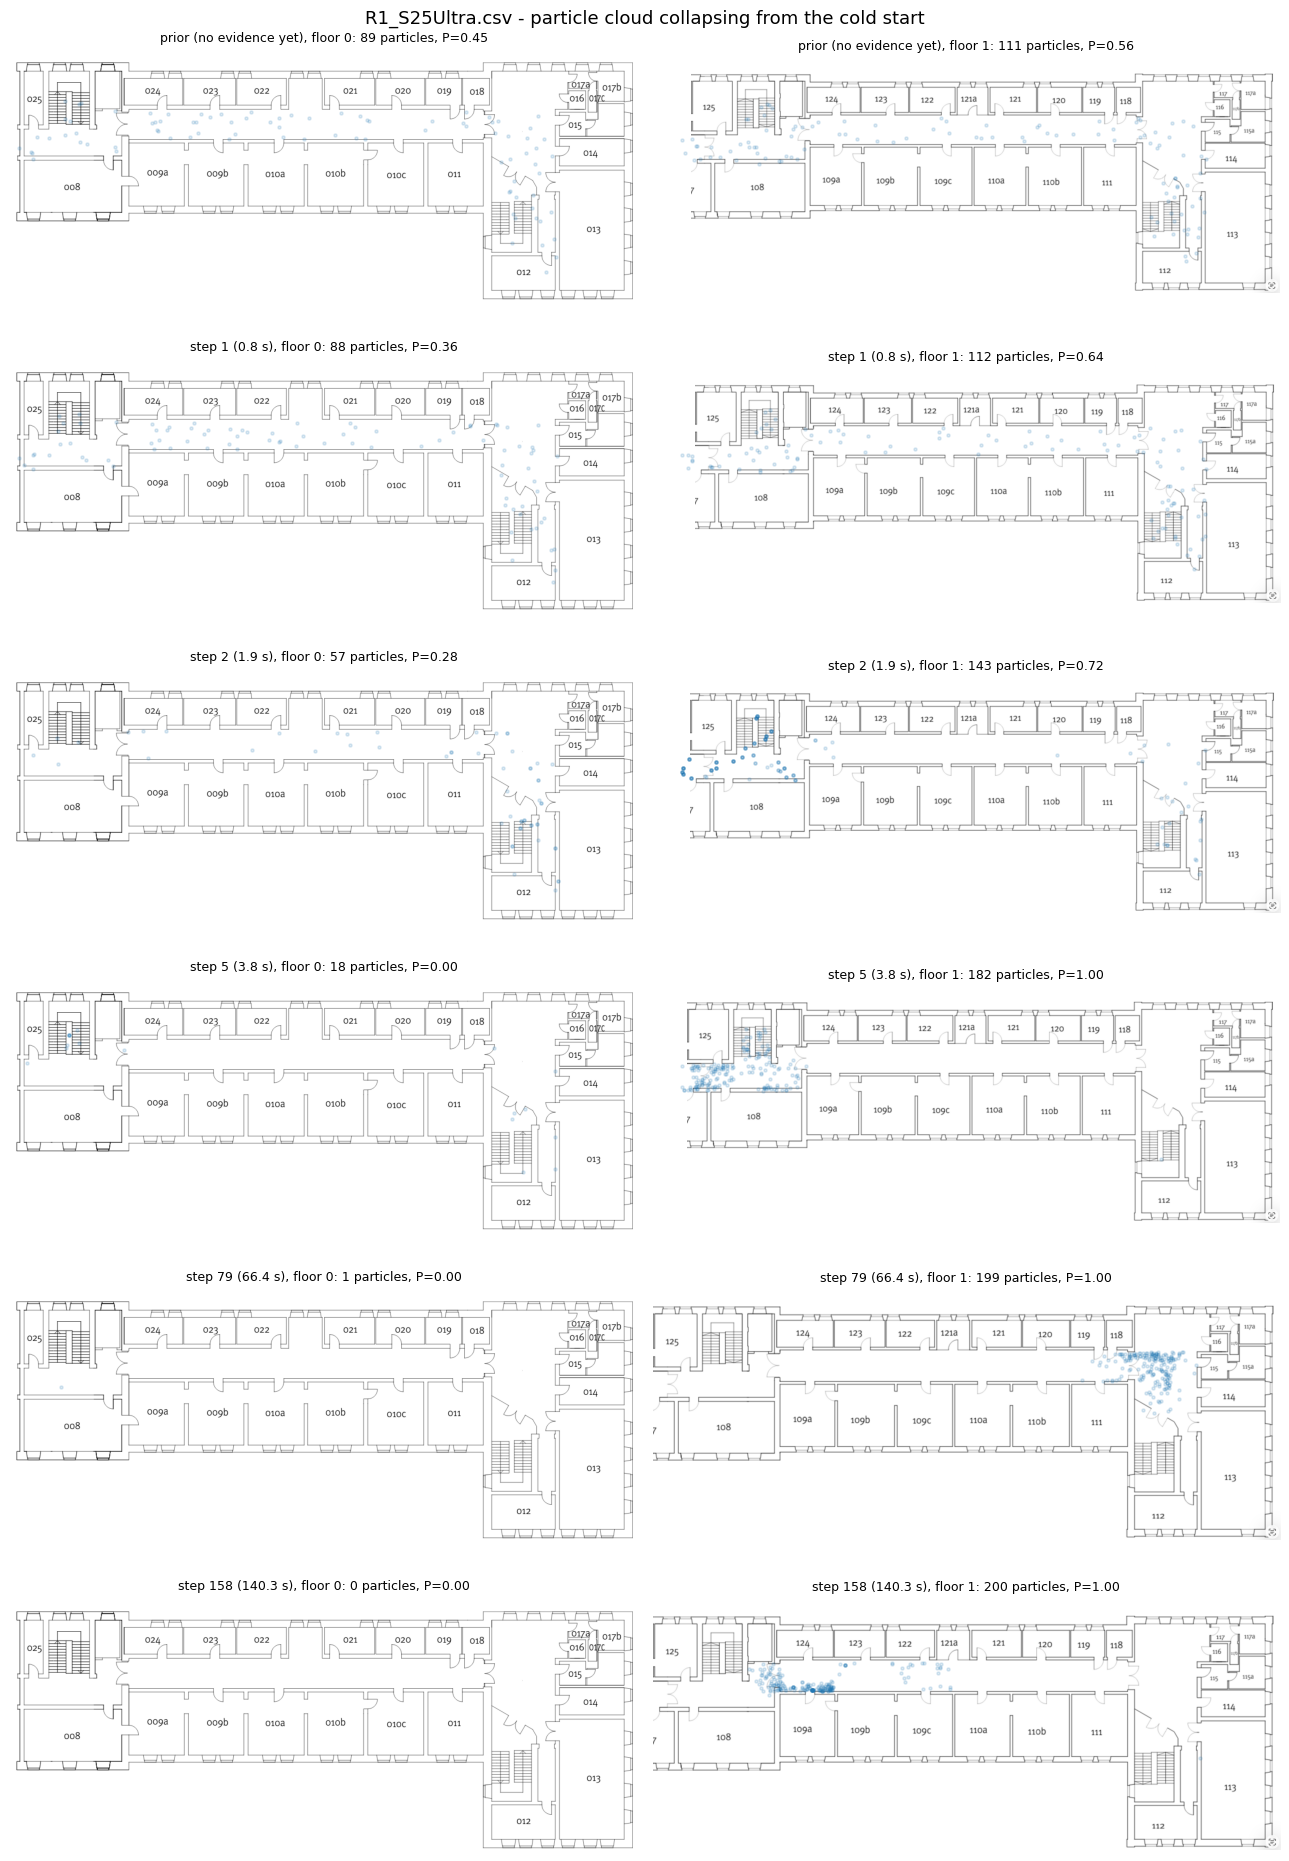

In [17]:
floor_images = {f: plt.imread(PLAN_DIR / plan_meta[f]['file']) for f in (0, 1)}

fig, axes = plt.subplots(len(SNAPSHOT_STEPS), 2, figsize=(13, 3.2 * len(SNAPSHOT_STEPS)),
                         squeeze=False)
for row, step_number in enumerate(SNAPSHOT_STEPS):
    sx, sy, sf = particle_snapshots[step_number]
    if step_number == 0:                       # the prior carries equal weights, so the
        label = 'prior (no evidence yet)'      # share of particles *is* the floor probability
        floor_prob = {f: float((sf == f).mean()) for f in (0, 1)}
    else:
        info = trajectory.loc[trajectory['step'].eq(step_number)].iloc[0]
        label = f'step {step_number} ({info.elapsed_s:.1f} s)'
        floor_prob = {1: info['floor1_prob'], 0: 1 - info['floor1_prob']}
    for col, floor in enumerate((0, 1)):
        ax = axes[row, col]
        ax.imshow(floor_images[floor])
        on = sf == floor
        if on.any():
            fx, fy = metric_to_pixel_xy(floor, sx[on], sy[on])
            ax.scatter(fx, fy, s=5, alpha=0.15, color='tab:blue')
        ax.set_title(f'{label}, floor {floor}: {int(on.sum())} particles, '
                     f'P={floor_prob[floor]:.2f}', fontsize=9)
        ax.set_axis_off()
fig.suptitle(f'{recording.name} - particle cloud collapsing from the cold start', fontsize=13)
fig.tight_layout()
plt.show()

## 6. Estimated trajectory

Points are coloured by elapsed time, so the direction of travel is visible: dark is the start of the
recording and bright is the end. A floor the filter never visits is left blank. Because this is a
cold start, the first few estimates may sit away from the true path until the particle cloud
collapses onto one corridor.

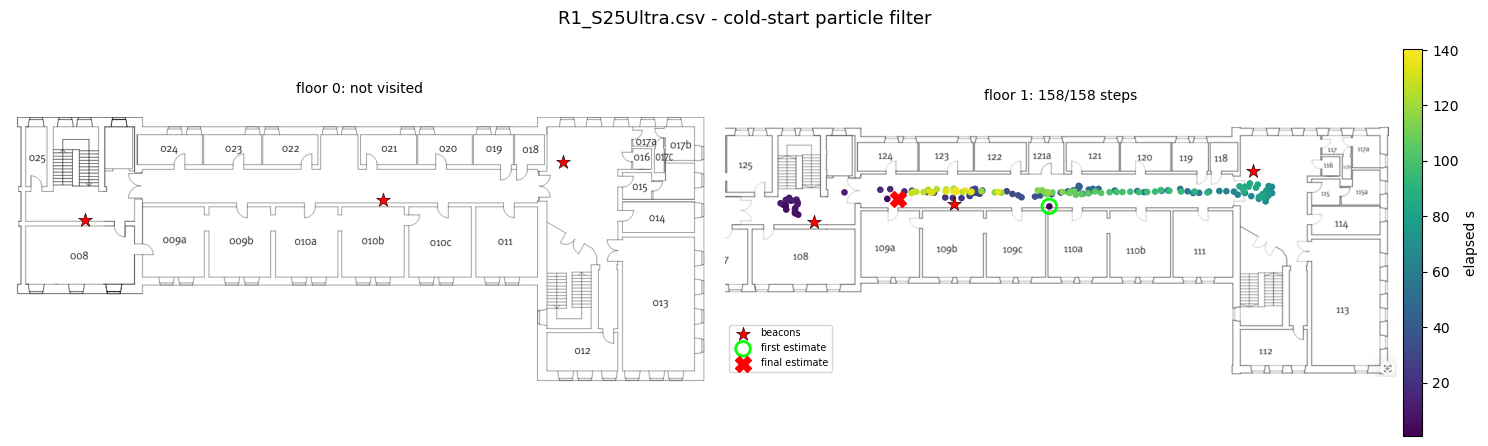

In [18]:
floor_images = {f: plt.imread(PLAN_DIR / plan_meta[f]['file']) for f in (0, 1)}
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, floor in zip(axes, (0, 1)):
    ax.imshow(floor_images[floor]); ax.set_axis_off()
    on_floor = trajectory.loc[trajectory['floor_hat'].eq(floor)]
    beacons = beacon_points.loc[beacon_points['floor'].eq(floor)]
    ax.scatter(beacons['pixel_x'], beacons['pixel_y'], marker='*', s=110, color='red',
               edgecolor='black', linewidth=0.4, zorder=4, label='beacons')
    if on_floor.empty:
        ax.set_title(f'floor {floor}: not visited', fontsize=10)
        continue
    px, py = metric_to_pixel_xy(floor, on_floor['x_m'].to_numpy(), on_floor['y_m'].to_numpy())
    dots = ax.scatter(px, py, c=on_floor['elapsed_s'], cmap='viridis', s=14, zorder=3)
    fig.colorbar(dots, ax=ax, fraction=0.03, pad=0.01, label='elapsed s')
    if on_floor['elapsed_s'].iloc[0] == trajectory['elapsed_s'].iloc[0]:
        ax.scatter(*metric_to_pixel_xy(floor, on_floor['x_m'].iloc[0], on_floor['y_m'].iloc[0]),
                   marker='o', s=110, facecolor='none', edgecolor='lime', linewidth=2,
                   zorder=5, label='first estimate')
    if on_floor['elapsed_s'].iloc[-1] == trajectory['elapsed_s'].iloc[-1]:
        ax.scatter(*metric_to_pixel_xy(floor, on_floor['x_m'].iloc[-1], on_floor['y_m'].iloc[-1]),
                   marker='X', s=130, color='red', zorder=5, label='final estimate')
    ax.set_title(f'floor {floor}: {len(on_floor)}/{len(trajectory)} steps', fontsize=10)
    ax.legend(loc='lower left', fontsize=7)
fig.suptitle(f'{recording.name} - cold-start particle filter', fontsize=13)
fig.tight_layout()
plt.show()

Generating GIF for 158 steps...


C:\Users\tanish\AppData\Local\Temp\ipykernel_12776\2458493486.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter_0 = axes[0].scatter([], [], cmap='viridis', s=40, zorder=3)
C:\Users\tanish\AppData\Local\Temp\ipykernel_12776\2458493486.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter_1 = axes[1].scatter([], [], cmap='viridis', s=40, zorder=3)


Saved GIF to R1_S25Ultra_trajectory.gif


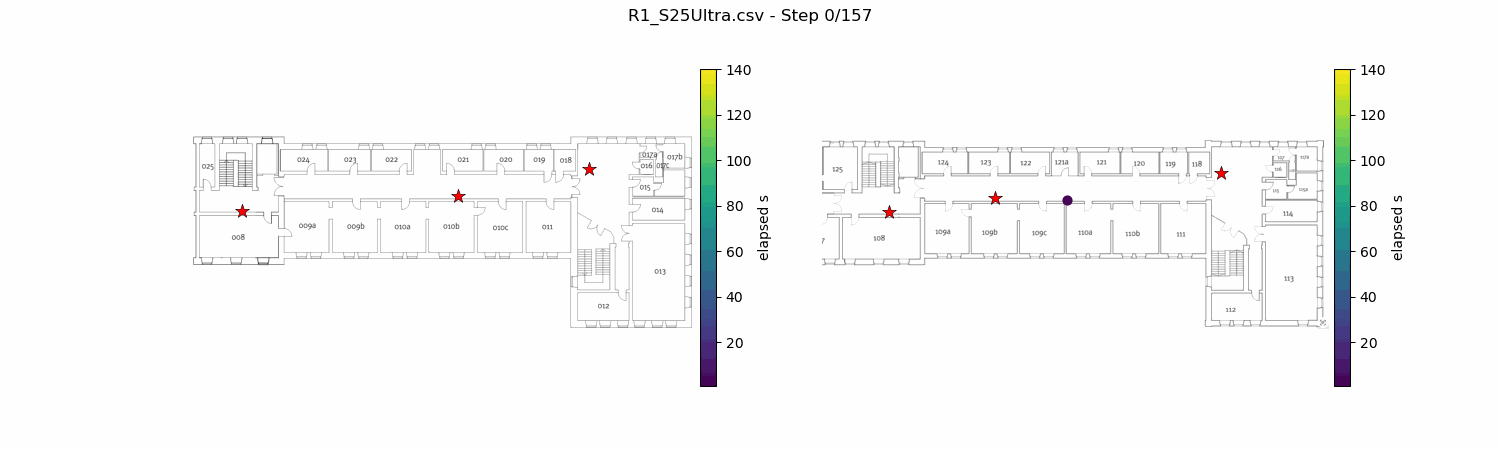

In [21]:
import matplotlib.animation as animation
from IPython.display import Image, display

print(f"Generating GIF for {len(trajectory)} steps...")
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, floor in zip(axes, (0, 1)):
    ax.imshow(floor_images[floor]); ax.set_axis_off()
    beacons = beacon_points.loc[beacon_points['floor'].eq(floor)]
    ax.scatter(beacons['pixel_x'], beacons['pixel_y'], marker='*', s=110, color='red',
               edgecolor='black', linewidth=0.4, zorder=4, label='beacons')

vmin_val = trajectory['elapsed_s'].min()
vmax_val = trajectory['elapsed_s'].max()

scatter_0 = axes[0].scatter([], [], cmap='viridis', s=40, zorder=3)
scatter_0.set_clim(vmin_val, vmax_val)

scatter_1 = axes[1].scatter([], [], cmap='viridis', s=40, zorder=3)
scatter_1.set_clim(vmin_val, vmax_val)

fig.colorbar(scatter_0, ax=axes[0], fraction=0.03, pad=0.01, label='elapsed s')
fig.colorbar(scatter_1, ax=axes[1], fraction=0.03, pad=0.01, label='elapsed s')

def update(frame):
    current_traj = trajectory.iloc[:frame+1]
    
    on_floor_0 = current_traj[current_traj['floor_hat'] == 0]
    if not on_floor_0.empty:
        px, py = metric_to_pixel_xy(0, on_floor_0['x_m'].to_numpy(), on_floor_0['y_m'].to_numpy())
        scatter_0.set_offsets(np.c_[px, py])
        scatter_0.set_array(on_floor_0['elapsed_s'].to_numpy())
    else:
        # Clear points if empty
        scatter_0.set_offsets(np.empty((0, 2)))
        
    on_floor_1 = current_traj[current_traj['floor_hat'] == 1]
    if not on_floor_1.empty:
        px, py = metric_to_pixel_xy(1, on_floor_1['x_m'].to_numpy(), on_floor_1['y_m'].to_numpy())
        scatter_1.set_offsets(np.c_[px, py])
        scatter_1.set_array(on_floor_1['elapsed_s'].to_numpy())
    else:
        # Clear points if empty
        scatter_1.set_offsets(np.empty((0, 2)))
        
    fig.suptitle(f'{recording.name} - Step {frame}/{len(trajectory)-1}')
    return scatter_0, scatter_1

ani = animation.FuncAnimation(fig, update, frames=len(trajectory), interval=100, blit=False)
gif_path = f"{recording.stem}_trajectory.gif"
ani.save(gif_path, writer='pillow', fps=10)
plt.close(fig)

print(f"Saved GIF to {gif_path}")
display(Image(filename=gif_path))
